In [7]:
# Student Name: Nowres Al-Rubaie
# Student ID: ALM19463316


In [8]:
#1 What is the percentage of the population that has been fully vaccinated in different countries?
# Import necessary libraries
import plotly.express as px  # Import Plotly Express for visualization
import pandas as pd  # Import pandas for data handling

# Load vaccination data from a CSV file
vaccination_data = pd.read_csv('vaccination-data.csv')

# Create a choropleth map using Plotly Express
fig = px.choropleth(vaccination_data,  # Use the vaccination data as the source
                    locations='ISO3',  # Use ISO3 codes to uniquely identify countries
                    color='PERSONS_FULLY_VACCINATED_PER100',  # Color countries based on fully vaccinated percentage
                    hover_name='Country',  # Display country names when hovering over them
                    color_continuous_scale='Viridis',  # Choose a color scale for the map
                    projection='natural earth'  # Use a natural earth projection for the map
                    )

# Update the layout of the figure
fig.update_layout(
    title='Fully Vaccinated Population Percentage by Country',  # Set the title of the map
    geo=dict(
        showcoastlines=True,  # Display coastlines on the map
        coastlinecolor="Black",  # Set the color of the coastlines to black
        showland=True,  # Display land areas on the map
        landcolor="white"  # Set the color of land areas to white
    )
)

# Show the figure
fig.show()  # Display the choropleth map


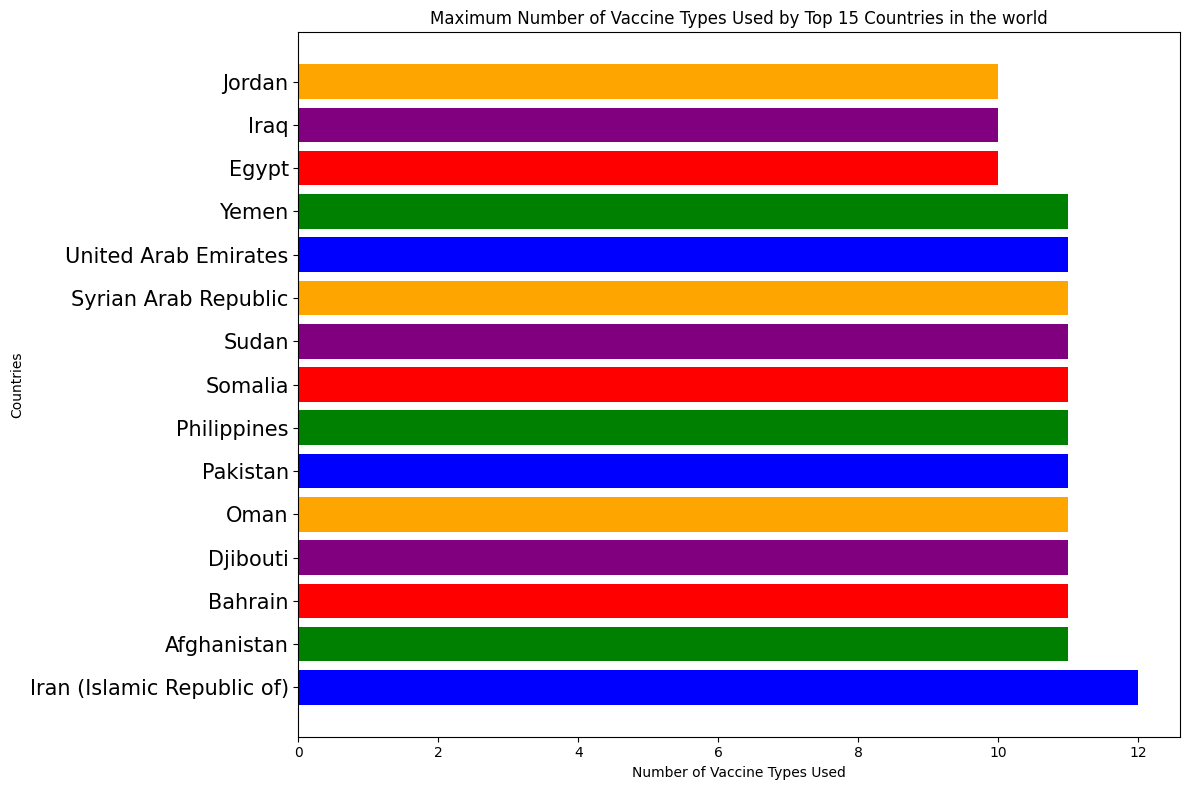

In [9]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file into a DataFrame
df = pd.read_csv('vaccination-data.csv')

# Sort the DataFrame by 'NUMBER_VACCINES_TYPES_USED' in descending order and select top 15
top_15_countries = df.nlargest(15, 'NUMBER_VACCINES_TYPES_USED')

# Define a list of colors (customize this list as needed)
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Set the figure size
plt.figure(figsize=(12, 8))

# Create a horizontal bar chart with different colors
plt.barh(top_15_countries['Country'], top_15_countries['NUMBER_VACCINES_TYPES_USED'], color=colors)

# Add labels and title
plt.xlabel('Number of Vaccine Types Used')  # X-axis label
plt.ylabel('Countries')  # Y-axis label
plt.title('Maximum Number of Vaccine Types Used by Top 15 Countries in the world')  # Chart title

# Set custom y-ticks with larger font size for better readability
plt.yticks(range(len(top_15_countries['Country'])), top_15_countries['Country'], fontsize=15)

# Ensure all labels and ticks fit within the figure
plt.tight_layout()

# Display the chart
plt.show()


<ipython-input-10-4ed94e5c8f38>:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-10-4ed94e5c8f38>:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



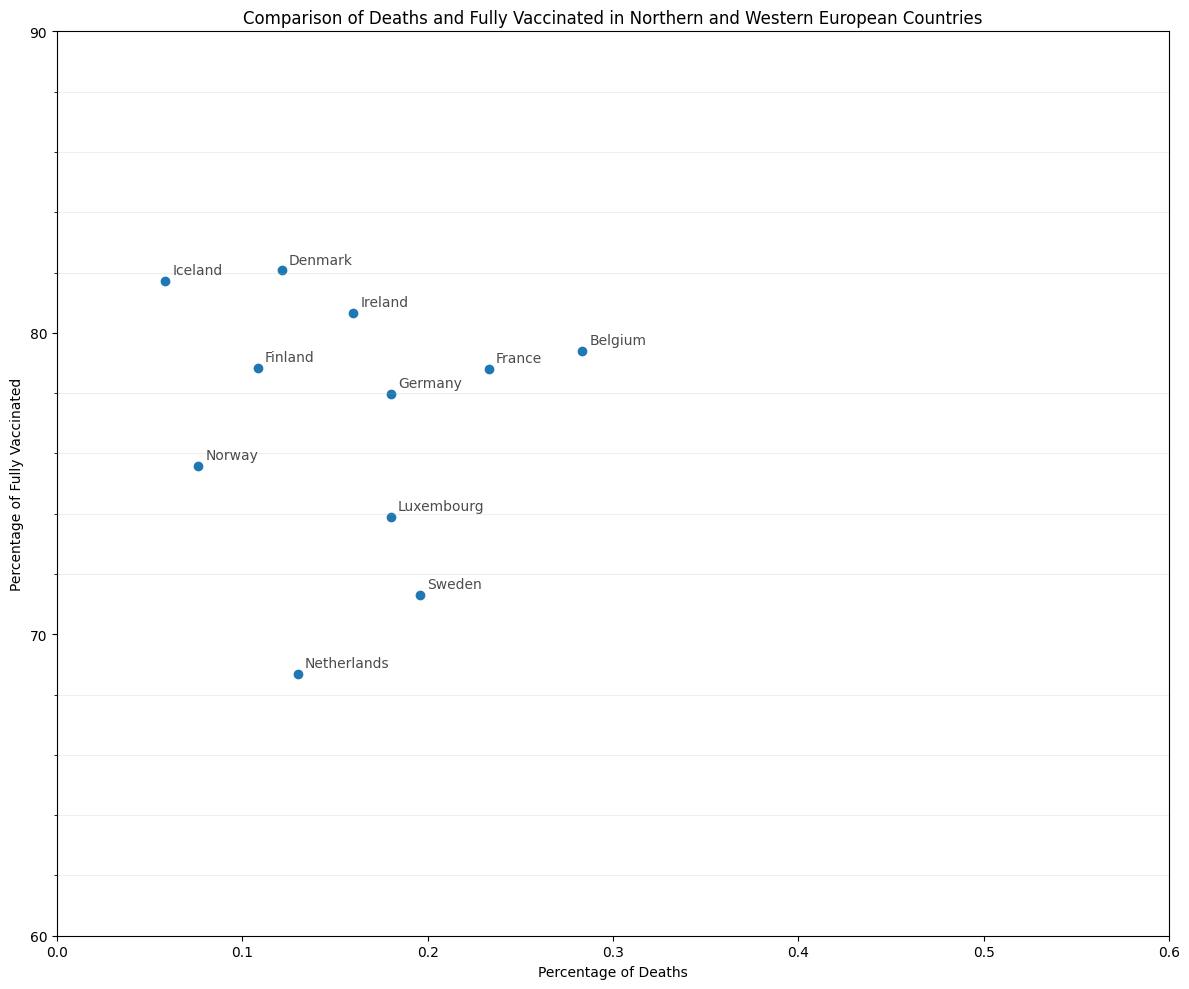

In [10]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Define a list of Northern and Western European countries
northern_western_european_countries = ['Sweden', 'Norway', 'Denmark', 'Finland', 'Iceland', 'Netherlands', 'Belgium', 'Luxembourg', 'France', 'Germany', 'United Kingdom', 'Ireland']

# Load data from the first CSV file
df_covid_data = pd.read_csv('WHO-COVID-19-global-table-data.csv')

# Load data from the second CSV file
df_vaccination_data = pd.read_csv('vaccination-data.csv')

# Filter data for Northern and Western European countries
df_covid_northern_western = df_covid_data[df_covid_data['Country'].isin(northern_western_european_countries)]
df_vaccination_northern_western = df_vaccination_data[df_vaccination_data['Country'].isin(northern_western_european_countries)]

# Calculate percentage of deaths per 100,000 population
df_covid_northern_western['Deaths_percentage'] = (df_covid_northern_western['Deaths - cumulative total per 100000 population'] / 100000) * 100

# Calculate percentage of persons fully vaccinated
df_vaccination_northern_western['Fully_Vaccinated_percentage'] = df_vaccination_northern_western['PERSONS_FULLY_VACCINATED_PER100']

# Merge DataFrames based on a common identifier (e.g., 'Country')
merged_df = pd.merge(df_covid_northern_western, df_vaccination_northern_western, left_on='Country', right_on='Country', how='inner')

# Create a scatter plot with larger figure size
plt.figure(figsize=(12, 10))

# Add scatter plot
plt.scatter(merged_df['Deaths_percentage'], merged_df['Fully_Vaccinated_percentage'])
plt.xlabel('Percentage of Deaths')
plt.ylabel('Percentage of Fully Vaccinated')
plt.title('Comparison of Deaths and Fully Vaccinated in Northern and Western European Countries')

# Annotate data points with country names and adjust positions
for i, country in enumerate(merged_df['Country']):
    plt.annotate(country, (merged_df['Deaths_percentage'][i], merged_df['Fully_Vaccinated_percentage'][i]), fontsize=10, alpha=0.7, xytext=(5,5), textcoords='offset points')

# Adjust the limits and ticks of the axes
plt.xlim(0, 0.6)  # Set x-axis limits from 0 to 0.6
plt.ylim(60, 90)  # Set y-axis limits from 60 to 90
plt.yticks(range(60, 91, 10))  # Set y-axis ticks to go up in 10s
plt.gca().yaxis.set_minor_locator(MultipleLocator(2))  # Increase the gap between minor ticks
plt.xticks([i/10 for i in range(0, 7)])  # Set x-axis ticks to go up in 0.1 increments
plt.grid(which='minor', alpha=0.2)  # Add gridlines for minor ticks

# Show the plot
plt.tight_layout()
plt.show()


<ipython-input-11-6e24c5918852>:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



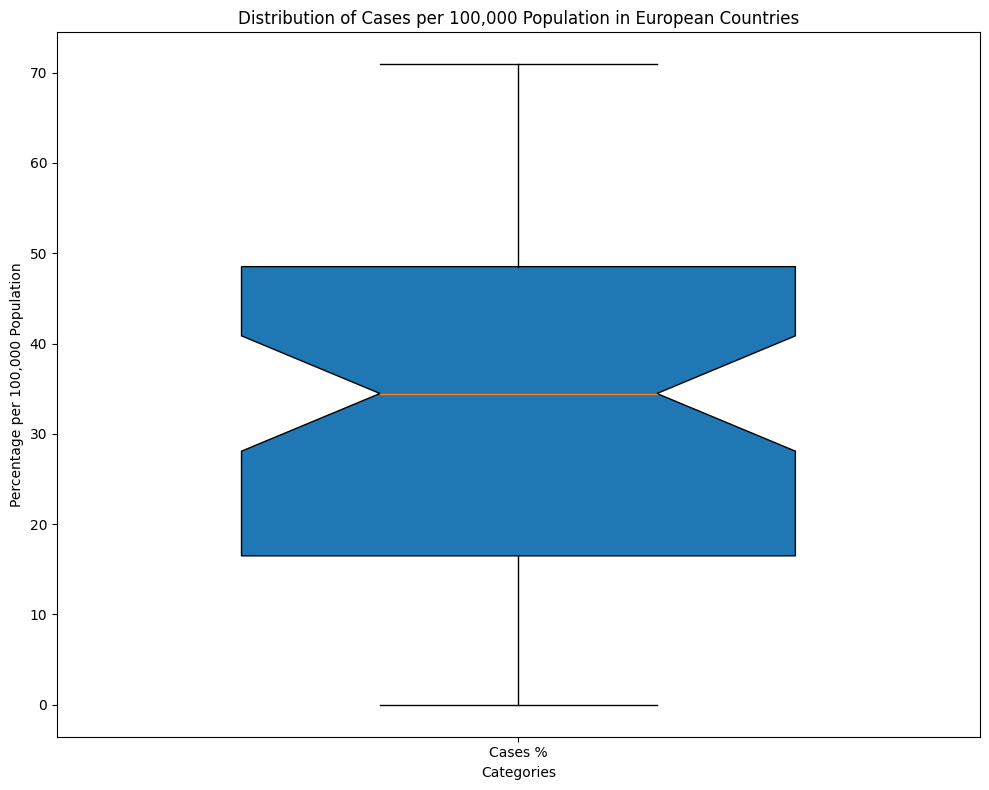

In [11]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load data from the CSV file
df_covid_data = pd.read_csv('WHO-COVID-19-global-table-data.csv')

# Filter data for European countries
df_covid_europe = df_covid_data[df_covid_data['WHO Region'] == 'Europe']

# Calculate percentage of cases per 100,000 population
df_covid_europe['Cases_percentage'] = (df_covid_europe['Cases - cumulative total per 100000 population'] / 100000) * 100

# Set up figure and axis for the boxplot
plt.figure(figsize=(10, 8))
ax = plt.gca()

# Create boxplot for Cases percentages
boxplot_data = [df_covid_europe['Cases_percentage']]  # Data to be plotted
positions = [1]  # Position of the boxplot on the x-axis
labels = ['Cases %']  # Labels for the boxplot

# Create the boxplot
plt.boxplot(boxplot_data, positions=positions, labels=labels, widths=0.6, patch_artist=True, vert=True, notch=True, showfliers=False)

# Set x-axis label
plt.xlabel('Categories')

# Set y-axis label
plt.ylabel('Percentage per 100,000 Population')

# Add title
plt.title('Distribution of Cases per 100,000 Population in European Countries')

# Show plot
plt.tight_layout()
plt.show()


<ipython-input-12-dc517a3aaebd>:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



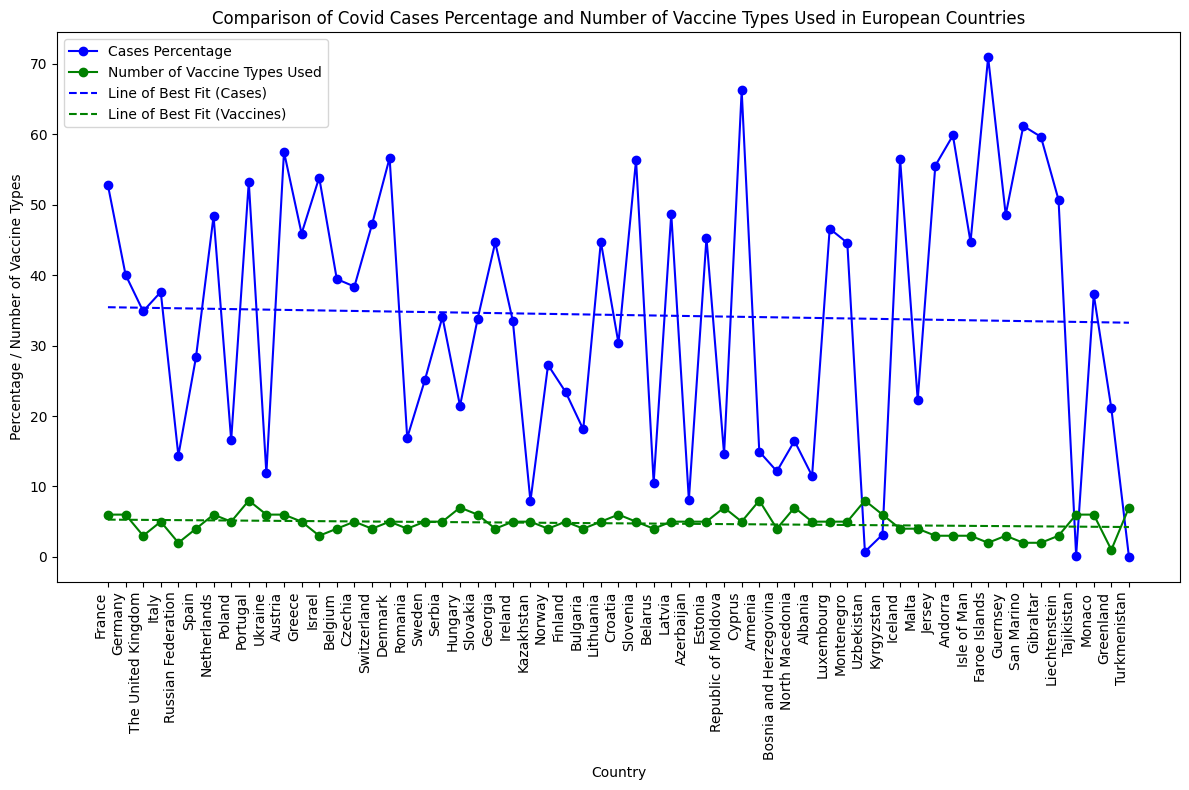

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data from the first CSV file (COVID-19 data)
df_covid_data = pd.read_csv('WHO-COVID-19-global-table-data.csv')

# Filter data for European countries
df_covid_europe = df_covid_data[df_covid_data['WHO Region'] == 'Europe']

# Calculate percentage of cases per 100,000 population
df_covid_europe['Cases_percentage'] = (df_covid_europe['Cases - cumulative total per 100000 population'] / 100000) * 100

# Load data from the second CSV file (Vaccination data)
df_vaccination_data = pd.read_csv('vaccination-data.csv')

# Merge DataFrames based on a common identifier (e.g., 'Country')
merged_df = pd.merge(df_covid_europe, df_vaccination_data, on='Country', how='inner')

plt.figure(figsize=(12, 8))  # Increase figure size for better spacing

plt.plot(merged_df['Country'], merged_df['Cases_percentage'], marker='o', label='Cases Percentage', color='blue')
plt.plot(merged_df['Country'], merged_df['NUMBER_VACCINES_TYPES_USED'], marker='o', label='Number of Vaccine Types Used', color='green')

# Add a line of best fit for blue data points
coefficients_blue = np.polyfit(range(len(merged_df)), merged_df['Cases_percentage'], 1)
line_of_best_fit_blue = np.polyval(coefficients_blue, range(len(merged_df)))
plt.plot(merged_df['Country'], line_of_best_fit_blue, color='blue', linestyle='--', label='Line of Best Fit (Cases)')

# Add a line of best fit for green data points
coefficients_green = np.polyfit(range(len(merged_df)), merged_df['NUMBER_VACCINES_TYPES_USED'], 1)
line_of_best_fit_green = np.polyval(coefficients_green, range(len(merged_df)))
plt.plot(merged_df['Country'], line_of_best_fit_green, color='green', linestyle='--', label='Line of Best Fit (Vaccines)')

plt.xlabel('Country')
plt.ylabel('Percentage / Number of Vaccine Types')
plt.title('Comparison of Covid Cases Percentage and Number of Vaccine Types Used in European Countries')
plt.xticks(rotation=90, ha='right')  # Rotate and align x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from being cut off
plt.legend()

plt.show()


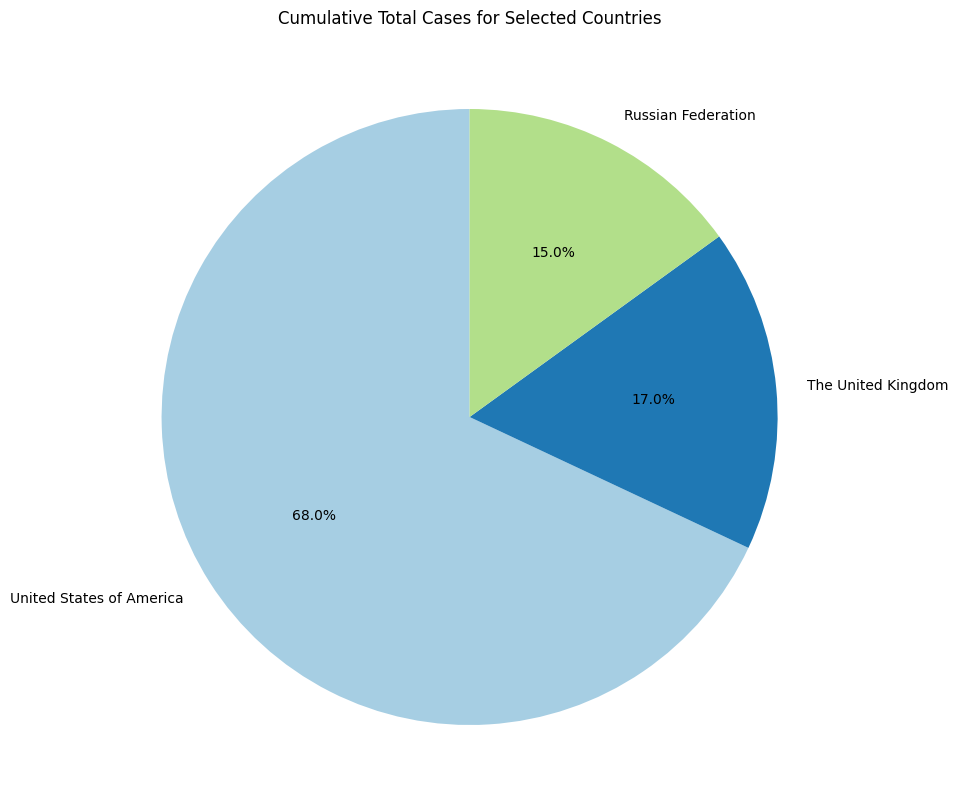

In [13]:
##ADDITIONAL VISUALISATION###

import pandas as pd
import matplotlib.pyplot as plt

# Load the data from the CSV file
file_path = 'WHO-COVID-19-global-table-data.csv'
df = pd.read_csv(file_path)

# Filter data for The United Kingdom, Russia, and USA
selected_countries = ['The United Kingdom', 'Russian Federation', 'United States of America']
filtered_df = df[df['Country'].isin(selected_countries)]

# Create a pie chart
plt.figure(figsize=(10, 10))
plt.pie(filtered_df['Cases - cumulative total'], labels=filtered_df['Country'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Cumulative Total Cases for Selected Countries')
plt.show()
